# Standard Mode Results 18 05
24 05

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import functions from evaluation.py (keep evaluation.py unchanged!)
from evaluation import (
    load_and_prepare_results,
    plot_overall_performance,
    plot_pairwise_comparison,
    plot_comparison_matrix,
    plot_task_variability,
    generate_llm_summary,
    add_task_zscore,
    plot_lowdata_with_standard_std,
    plot_overall_performance_bar,
    plot_lowdata_with_standard_zscore,

)

%matplotlib inline

### start

In [2]:
import matplotlib.patches as mpatches



def plot_pairwise_direction_significance_heatmap(
    pairwise_df: pd.DataFrame,
    feature_order: list[str],
    metric: str = "MCC",
    p_col: str = "p_adj",
    delta_col: str = "mean_delta_i_minus_j",
    feature_i_col: str = "feature_i",
    feature_j_col: str = "feature_j",
    figsize: tuple[float, float] = (9, 8),
    sig_threshold: float = 0.05,   # ← NEW: grey out non-significant cells
    max_logp: float | None = None,
    title_prefix: str | None = None,
    save_path: str | None = None,
):
    n = len(feature_order)
    score = pd.DataFrame(np.nan, index=feature_order, columns=feature_order)
    annot = pd.DataFrame("",    index=feature_order, columns=feature_order)
    seen  = set()  # ← duplicate guard

    for _, row in pairwise_df.iterrows():
        i, j = row[feature_i_col], row[feature_j_col]
        if i not in feature_order or j not in feature_order:
            print(f"[SKIP] unknown feature: {i!r} or {j!r}")
            continue

        p     = row[p_col]
        delta = row[delta_col]
        if pd.isna(p) or pd.isna(delta) or p <= 0:
            continue

        i_pos, j_pos = feature_order.index(i), feature_order.index(j)
        if i_pos == j_pos:
            continue

        # Canonicalise to upper triangle
        if i_pos < j_pos:
            row_feat, col_feat, signed_delta = i, j,  delta
        else:
            row_feat, col_feat, signed_delta = j, i, -delta

        pair_key = (row_feat, col_feat)
        if pair_key in seen:                          # ← duplicate guard
            print(f"[WARN] duplicate pair {pair_key}, keeping first.")
            continue
        seen.add(pair_key)

        logp         = -np.log10(p)
        signed_score = np.sign(signed_delta) * logp

        # ← Grey out non-significant: set score to 0 so it maps to white
        if p >= sig_threshold:
            signed_score = 0.0

        score.loc[row_feat, col_feat] = signed_score

        # Annotation: p-value + stars
        stars = (
            "***" if p < 0.001 else
            "**"  if p < 0.01  else
            "*"   if p < 0.05  else
            "ns"
        )
        annot.loc[row_feat, col_feat] = f"{p:.1e}\n{stars}"

    if max_logp is None:
        max_abs = np.nanmax(np.abs(score.values))
        max_logp = max_abs if np.isfinite(max_abs) and max_abs > 0 else 1.0

    # Mask everything except upper triangle
    mask = pd.DataFrame(True, index=feature_order, columns=feature_order)
    for r in range(n):
        for c in range(r + 1, n):           # strict upper triangle only
            mask.iloc[r, c] = False         # unmask upper triangle
    # Also unmask cells that were explicitly filled (handles non-square edge cases)
    mask = mask | score.isna()

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        score,
        mask=mask,
        annot=annot,
        fmt="",
        cmap="RdBu",
        center=0,
        vmin=-max_logp,
        vmax=max_logp,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": r"$\mathrm{sign}(\Delta) \times -\log_{10}(p)$"},
    )

    ax.set_title(f"{title_prefix} Pairwise Wilcoxon comparisons - {metric}", fontsize=18)
    ax.set_xlabel("Column model (j)", fontsize=17)
    ax.set_ylabel("Row model (i)", fontsize=17)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")  # one-liner
    ax.tick_params(axis="y", rotation=0, labelsize=13)
    ax.tick_params(axis="x", labelsize=13 )

    # Manual legend for direction + ns
    handles = [
        mpatches.Patch(color="#2166ac", label="Row model better (blue)"),
        mpatches.Patch(color="#d6604d", label="Column model better (red)"),
        mpatches.Patch(color="#f7f7f7", label=f"ns (p ≥ {sig_threshold})"),
    ]
    ax.legend(handles=handles, loc="lower left",
              bbox_to_anchor=(0, -0.35), ncol=3, fontsize=11, frameon=False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax, score, annot

In [2]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_celltype_18_05_results"

v1 = pd.read_parquet(os.path.join(dir_path, "test_files_standard_celltype_18_05.parquet"))
v1


,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,balanced_acc,MCC,F1_macro,...,n_valid_donors,proba_unavailable,donor_metric_error,feature,skip_reason,n_missing,error,AUROC,AUPRC,error_type
0,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.927052,0.977830,0.936058,...,2.0,None,None,raw_lognorm,None,NaN,None,NaN,NaN,None
1,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.911642,0.970165,0.924670,...,2.0,None,None,raw_pca50,None,NaN,None,NaN,NaN,None
2,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.613374,0.781188,0.575650,...,2.0,None,None,random_proj50,None,NaN,None,NaN,NaN,None
3,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.906401,0.962061,0.877485,...,2.0,None,None,obsm[scvi],None,NaN,None,NaN,NaN,None
4,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.792328,0.688977,0.705164,...,2.0,True,None,obsm[geneformer],None,NaN,None,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2608,fold_5,359542.0,72734.0,None,ac0c6561-7a48-4185-af6f-af799f699172,29959.0,8.0,0.983854,0.990493,0.976696,...,7.0,None,None,obsm[scvi],None,NaN,None,NaN,NaN,None
2609,fold_5,359542.0,72734.0,None,ac0c6561-7a48-4185-af6f-af799f699172,29959.0,8.0,0.975485,0.981014,0.977205,...,7.0,True,None,obsm[geneformer],None,NaN,None,NaN,NaN,None
2610,fold_5,359542.0,72734.0,None,ac0c6561-7a48-4185-af6f-af799f699172,29959.0,8.0,0.995457,0.996188,0.995371,...,7.0,True,None,obsm[tf-sapiens],None,NaN,None,NaN,NaN,None
2611,fold_5,359542.0,72734.0,None,ac0c6561-7a48-4185-af6f-af799f699172,29959.0,8.0,0.995891,0.996447,0.996035,...,7.0,True,None,obsm[tf-exemplar-human],None,NaN,None,NaN,NaN,None


In [3]:
pd.crosstab(v1.dataset_id, v1.feature)

feature,obsm[bmfm],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,5,5,5,5,5,5,5,5
0b75c598-0893-4216-afe8-5414cab7739d,5,5,5,5,5,5,5,5
0bc7235a-ae5a-479d-a487-510435377e55,5,5,5,5,5,5,5,5
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,5,5,5,5,5,5,5,5
19e46756-9100-4e01-8b0e-23b557558a4c,5,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5,5,5,5,5,5,5,5
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,5,5,5,5,5,5,5,5
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5,5,5,5,5,5,5,5


In [4]:
v1.dataset_id.nunique()

74

In [5]:
v1[v1.dataset_id =='e40c6272-af77-4a10-9385-62a398884f27']

,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,balanced_acc,MCC,F1_macro,...,n_valid_donors,proba_unavailable,donor_metric_error,feature,skip_reason,n_missing,error,AUROC,AUPRC,error_type
1290,None,NaN,NaN,None,e40c6272-af77-4a10-9385-62a398884f27,NaN,NaN,NaN,NaN,NaN,...,NaN,None,None,None,missing_cache_files,1.0,None,NaN,NaN,None


In [6]:

v2 = pd.read_parquet(os.path.join(dir_path, "test_files_standard_celltype_18_05_v2.parquet"))
v2


,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,balanced_acc,MCC,F1_macro,...,worst_donor_acc,std_donor_acc,n_valid_donors,feature,skip_reason,n_missing,donor_metric_error,AUROC_ovr,AUROC,AUPRC
0,fold_1,190035.0,85917.0,None,7b20c613-9add-43d1-87e9-defd3d9b9f8c,22399.0,8.0,0.933648,0.956042,0.934372,...,0.845085,0.030908,38.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN
1,fold_2,178615.0,97337.0,None,7b20c613-9add-43d1-87e9-defd3d9b9f8c,22399.0,8.0,0.950622,0.954982,0.949225,...,0.896701,0.029167,37.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN
2,fold_3,183254.0,92698.0,None,7b20c613-9add-43d1-87e9-defd3d9b9f8c,22399.0,8.0,0.958121,0.960280,0.958228,...,0.850746,0.030316,43.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN
3,fold_1,36195.0,4665.0,None,87a06a2a-16c6-42f7-af1b-529fad431051,22696.0,5.0,0.983890,0.985238,0.986261,...,0.989273,0.004230,2.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN
4,fold_2,35891.0,4969.0,None,87a06a2a-16c6-42f7-af1b-529fad431051,22696.0,5.0,0.989080,0.990930,0.990342,...,0.990083,0.003439,2.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,fold_1,178153.0,42002.0,None,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,32876.0,11.0,0.959750,0.986541,0.956804,...,0.976216,0.006770,10.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN
298,fold_2,176557.0,43598.0,None,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,32876.0,11.0,0.960269,0.988051,0.964918,...,0.976897,0.005753,9.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN
299,fold_3,171468.0,48687.0,None,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,32876.0,11.0,0.968405,0.980375,0.961077,...,0.944796,0.016138,9.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN
300,fold_4,169844.0,50311.0,None,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,32876.0,11.0,0.967195,0.988665,0.969909,...,0.968384,0.011269,9.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN,NaN


In [7]:
pd.crosstab(v2.dataset_id, v2.feature)

feature,obsm[bmfm_var1]
dataset_id,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,5
0b75c598-0893-4216-afe8-5414cab7739d,3
0bc7235a-ae5a-479d-a487-510435377e55,5
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,4
19e46756-9100-4e01-8b0e-23b557558a4c,5
...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,5
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5


In [8]:
v1[~v1['dataset_id'].isin(v2['dataset_id'])]

,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,balanced_acc,MCC,F1_macro,...,n_valid_donors,proba_unavailable,donor_metric_error,feature,skip_reason,n_missing,error,AUROC,AUPRC,error_type


In [9]:
v1.skip_reason.unique()

array([None, 'missing_cache_files'], dtype=object)

In [10]:

v3 = pd.read_parquet(os.path.join(dir_path, "test_files_standard_celltype_18_05_v3.parquet"))
v3


,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,balanced_acc,MCC,F1_macro,...,worst_donor_acc,std_donor_acc,n_valid_donors,feature,AUROC_ovr,donor_metric_error,skip_reason,n_missing,AUROC,AUPRC
0,fold_1,82621.0,15984.0,None,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.873214,0.908360,0.899320,...,0.924770,0.023179,3.0,obsm[bmfm_WCED10],NaN,None,None,NaN,NaN,NaN
1,fold_1,82621.0,15984.0,None,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.964118,0.975877,0.971161,...,0.978270,0.008366,3.0,obsm[bmfm_MLMMUL],NaN,None,None,NaN,NaN,NaN
2,fold_2,83943.0,14662.0,None,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.915114,0.914349,0.906796,...,0.956192,0.005290,2.0,obsm[bmfm_WCED10],NaN,None,None,NaN,NaN,NaN
3,fold_2,83943.0,14662.0,None,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.967103,0.980266,0.973791,...,0.988862,0.002702,2.0,obsm[bmfm_MLMMUL],NaN,None,None,NaN,NaN,NaN
4,fold_3,63956.0,34649.0,None,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.920534,0.930846,0.928025,...,0.951210,0.009716,3.0,obsm[bmfm_WCED10],NaN,None,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,fold_3,812706.0,109749.0,None,1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1,17797.0,31.0,0.863778,0.890347,0.839146,...,0.656023,0.084682,35.0,obsm[bmfm_MLMMUL],NaN,None,None,NaN,NaN,NaN
591,fold_4,655643.0,266812.0,None,1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1,17797.0,31.0,0.905692,0.882230,0.892031,...,0.737188,0.049095,44.0,obsm[bmfm_WCED10],NaN,None,None,NaN,NaN,NaN
592,fold_4,655643.0,266812.0,None,1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1,17797.0,31.0,0.903035,0.882432,0.884668,...,0.678055,0.053639,44.0,obsm[bmfm_MLMMUL],NaN,None,None,NaN,NaN,NaN
593,fold_5,740327.0,182128.0,None,1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1,17797.0,31.0,0.893241,0.884886,0.878820,...,0.571429,0.082457,45.0,obsm[bmfm_WCED10],NaN,None,None,NaN,NaN,NaN


In [11]:
pd.crosstab(v3.dataset_id, v3.feature)

feature,obsm[bmfm_MLMMUL],obsm[bmfm_WCED10]
dataset_id,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,5,5
0b75c598-0893-4216-afe8-5414cab7739d,3,3
0bc7235a-ae5a-479d-a487-510435377e55,5,5
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,4,4
19e46756-9100-4e01-8b0e-23b557558a4c,5,5
...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5,5
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,5,5
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5,5


In [ ]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_celltype_18_05_results"

# Get all parquet files
files = glob.glob(os.path.join(dir_path, "*.parquet"))

# Read and concatenate
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df

In [9]:

df = pd.concat([v1, v2 ,v3], ignore_index=True)
df

,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,balanced_acc,MCC,F1_macro,...,n_valid_donors,proba_unavailable,donor_metric_error,feature,skip_reason,n_missing,error,AUROC,AUPRC,error_type
0,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.927052,0.977830,0.936058,...,2.0,None,None,raw_lognorm,None,NaN,None,NaN,NaN,None
1,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.911642,0.970165,0.924670,...,2.0,None,None,raw_pca50,None,NaN,None,NaN,NaN,None
2,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.613374,0.781188,0.575650,...,2.0,None,None,random_proj50,None,NaN,None,NaN,NaN,None
3,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.906401,0.962061,0.877485,...,2.0,None,None,obsm[scvi],None,NaN,None,NaN,NaN,None
4,fold_1,13824.0,2050.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,0.792328,0.688977,0.705164,...,2.0,True,None,obsm[geneformer],None,NaN,None,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3505,fold_3,812706.0,109749.0,None,1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1,17797.0,31.0,0.863778,0.890347,0.839146,...,35.0,True,None,obsm[bmfm_MLMMUL],None,NaN,NaN,NaN,NaN,NaN
3506,fold_4,655643.0,266812.0,None,1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1,17797.0,31.0,0.905692,0.882230,0.892031,...,44.0,True,None,obsm[bmfm_WCED10],None,NaN,NaN,NaN,NaN,NaN
3507,fold_4,655643.0,266812.0,None,1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1,17797.0,31.0,0.903035,0.882432,0.884668,...,44.0,True,None,obsm[bmfm_MLMMUL],None,NaN,NaN,NaN,NaN,NaN
3508,fold_5,740327.0,182128.0,None,1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1,17797.0,31.0,0.893241,0.884886,0.878820,...,45.0,True,None,obsm[bmfm_WCED10],None,NaN,NaN,NaN,NaN,NaN


In [10]:
pd.crosstab(df.dataset_id, df.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,5,5,5,5,5,5,5,5,5,5,5
0b75c598-0893-4216-afe8-5414cab7739d,5,3,3,3,5,5,5,5,5,5,5
0bc7235a-ae5a-479d-a487-510435377e55,5,5,5,5,5,5,5,5,5,5,5
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,5,4,4,4,5,5,5,5,5,5,5
19e46756-9100-4e01-8b0e-23b557558a4c,5,5,5,5,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5,5,5,5,5,5,5,5,5,5,5
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,5,5,5,5,5,5,5,5,5,5,5
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5,5,5,5,5,5,5,5,5,5,5


In [11]:
df.to_parquet("/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_celltype_18_05_results/test_files_standard_celltype_18_05_final.parquet")

## 2. Load and Prepare Results

In [3]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_celltype_18_05_results/test_files_standard_celltype_18_05_final.parquet"
df = load_and_prepare_results(parquet_path)

print(f"After filtering (errors/skips removed):")
print(f"  Total rows: {len(df):,}")
print(f"  Unique tasks: {df['task_id'].nunique()}")
print(f"  Features: {sorted(df['feature_clean'].unique())}")
print(f"\nSample:")
df[['task_id', 'fold', 'feature_clean', 'MCC', 'balanced_acc', 'F1_macro']].head(8) 

After filtering (errors/skips removed):
  Total rows: 3,464
  Unique tasks: 65
  Features: ['BMFM-CONCAT', 'BMFM_BW', 'BMFM_LM', 'BMFM_LW', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-EXEMPLAR-HUMAN', 'TF-SAPIENS', 'random_proj50']

Sample:


,task_id,fold,feature_clean,MCC,balanced_acc,F1_macro
0,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,fold_1,Raw Log-norm,0.977830,0.927052,0.936058
1,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,fold_1,PCA-50,0.970165,0.911642,0.924670
2,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,fold_1,random_proj50,0.781188,0.613374,0.575650
3,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,fold_1,SCVI,0.962061,0.906401,0.877485
4,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,fold_1,GENEFORMER,0.688977,0.792328,0.705164
5,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,fold_1,TF-SAPIENS,0.961731,0.925863,0.918880
6,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,fold_1,TF-EXEMPLAR-HUMAN,0.967909,0.931224,0.909502
7,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,fold_1,BMFM_LW,0.965939,0.897140,0.910447


In [4]:
feature_order = [ 'Raw Log-norm', 'PCA-50', 'TF-SAPIENS', 'BMFM-CONCAT', 'GENEFORMER', 'SCVI', 'random_proj50']

In [5]:
df= df.query('feature_clean.isin(@feature_order)')

In [6]:
from feature_colors import  get_palette
palette = get_palette(feature_order)
palette_dict = dict(zip(feature_order, palette))  # Create dict from list

## rank-based Demšar-style

### freidman corrected 20 08

In [7]:
from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar)

Datasets before dropna: 65, after: 62 (3 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (62, 7)  (T=62 datasets, M=7 models)

=== Friedman Test ===
T=62 tasks, M=7 models
Chi² = 309.6636, p = 6.9455e-64
Iman-Davenport F = 303.0248, p = 1.1102e-16
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
Raw Log-norm     1.6452
TF-SAPIENS       2.3387
BMFM-CONCAT      2.8387
PCA-50           3.3387
SCVI             5.1129
GENEFORMER       5.7258
random_proj50    7.0000
Nemenyi CD (alpha=0.05, M=7, T=62): 1.1442
Cell-type average ranks (dataset-corrected):
feature_clean
Raw Log-norm     1.645
TF-SAPIENS       2.339
BMFM-CONCAT      2.839
PCA-50           3.339
SCVI             5.113
GENEFORMER       5.726
random_proj50    7.000
dtype: float64
T = 62 (datasets)

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_delta_i_m

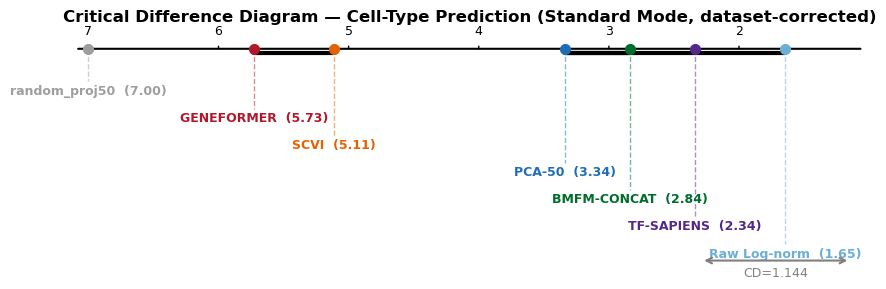

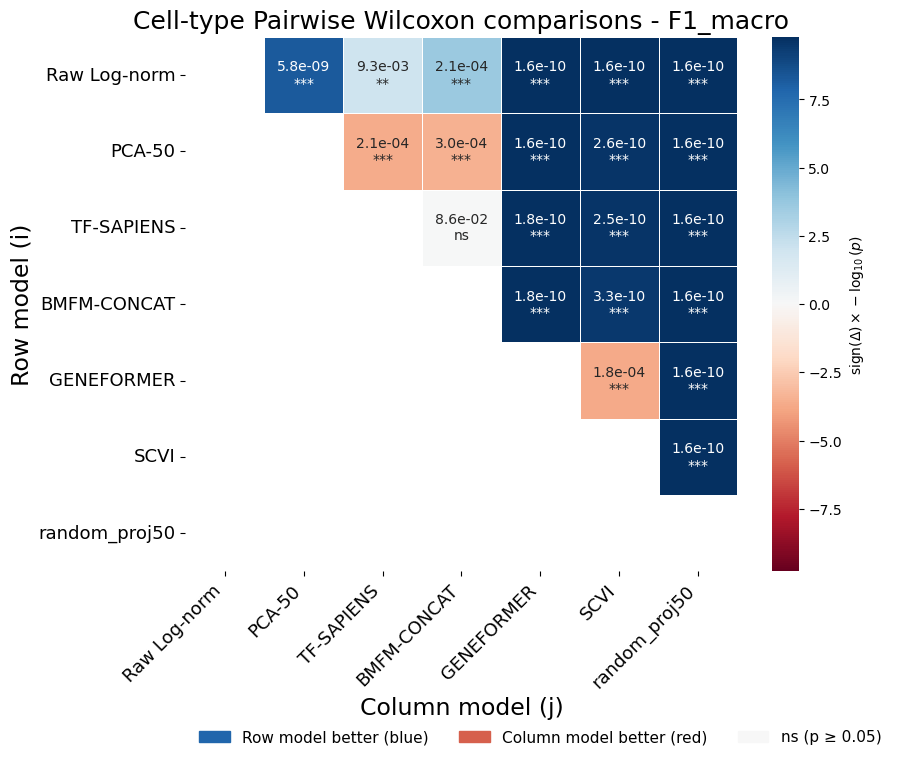

In [8]:
celltype_results = friedman_analysis(
    df=df,          # <-- swap to cell-type df
    task_col='dataset_id',            # <-- swap: no composite task_id for cell-type
    dataset_col='dataset_id',         # no-op here, safe to keep
    feature_col='feature_clean',
    metric='F1_macro',
    exclude_features=[],
    alpha=0.05,
    color_map=palette_dict,
    title='Critical Difference Diagram — Cell-Type Prediction (Standard Mode, dataset-corrected)',
    figsize=(9, 3),
)

print('Cell-type average ranks (dataset-corrected):')
print(celltype_results['friedman_results']['avg_ranks'].round(3))
print(f"T = {celltype_results['friedman_results']['T']} (datasets)")

pairwise_df_ct = pairwise_wilcoxon_holm(
    celltype_results["score_matrix"],
    alpha=0.05,
)

fig, ax, score, annot = plot_pairwise_direction_significance_heatmap(
    pairwise_df_ct,
    feature_order=feature_order,
    metric="F1_macro",
    title_prefix='Cell-type',
)

In [10]:
fig.savefig("./plots_brief/test_files_standard_celltype_18_05_final_F1_friW.png", dpi=300, bbox_inches="tight")

In [9]:
from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar)

In [10]:
import importlib
import friedman_ranking
importlib.reload(friedman_ranking)

from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar, run_friedman_per_nperclass, plot_lowdata_ranks_with_standard)

In [11]:
import importlib
import evaluation
importlib.reload(evaluation)

from evaluation import ( plot_overall_performance_bar)

Tasks before dropna: 65, after: 62 (3 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (62, 7)  (T=62 tasks, M=7 models)

=== Friedman Test ===
T=62 tasks, M=7 models
Chi² = 308.7166, p = 1.1084e-63
Iman-Davenport F = 297.5774, p = 1.1102e-16
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
Raw Log-norm     1.7903
TF-SAPIENS       2.2419
BMFM-CONCAT      2.8226
PCA-50           3.2419
SCVI             5.2419
GENEFORMER       5.6613
random_proj50    7.0000
Nemenyi CD (alpha=0.05, M=7, T=62): 1.1442

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_delta_i_minus_j  p_raw  p_holm  significant
  GENEFORMER random_proj50                0.3301 0.0000  0.0000         True
Raw Log-norm random_proj50                0.4277 0.0000  0.0000         True
Raw Log-norm          SCVI                0.0798 0.0000  0.0000       

ValueError: too many values to unpack (expected 2)

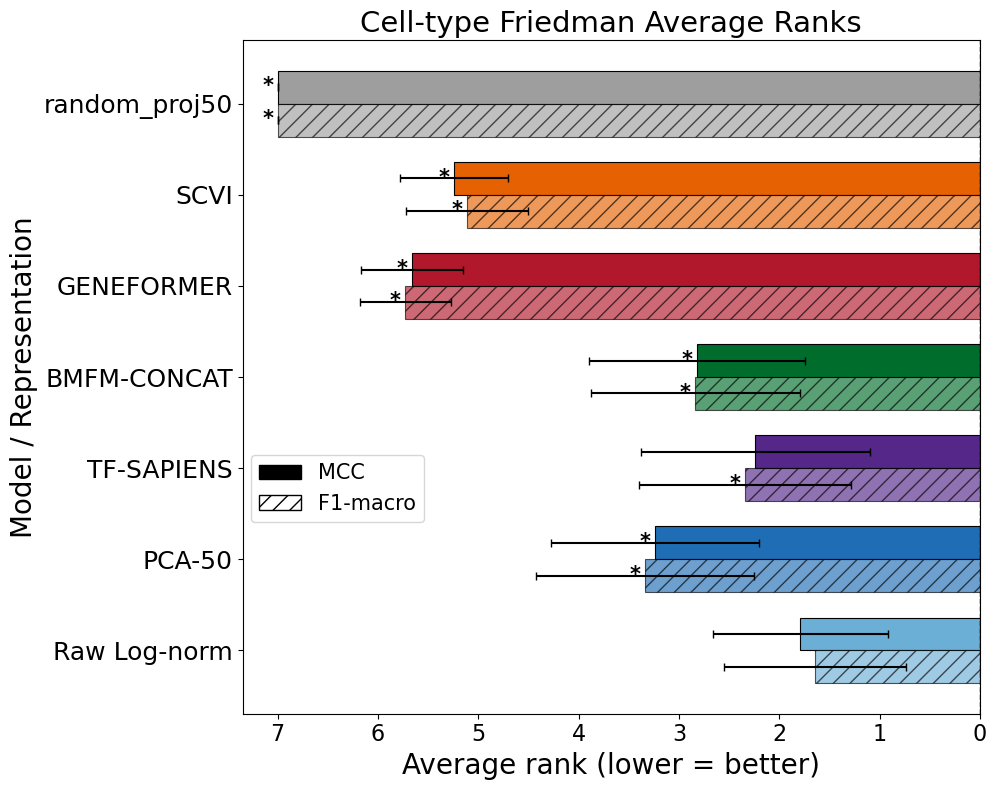

In [12]:


fig, ax = plot_friedman_as_bar(#, summary
    df=df,
    plot_overall_performance_bar=plot_overall_performance_bar,  # your function
    task_col="dataset_id",
    metrics=("MCC", "F1_macro"),
    exclude_features=[],
    feature_order=feature_order,
    color_map=palette_dict,
    figsize=(10, 8),
    errorbar='std',
    title_prefix='Cell-type',
    save_path="./plots_brief/test_files_standard_celltype_18_05_final_mccF1_fri_std_str.png",
)

# pseudobulk Mode Results 18 05
24 05

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import functions from evaluation.py (keep evaluation.py unchanged!)
from evaluation import (
    load_and_prepare_results,
    plot_overall_performance,
    plot_pairwise_comparison,
    plot_comparison_matrix,
    plot_task_variability,
    generate_llm_summary,
    add_task_zscore,
    plot_lowdata_with_standard_std,
    plot_overall_performance_bar,
    plot_lowdata_with_standard_zscore,

)

%matplotlib inline

### start

In [2]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_pseudobulk_celltype_18_05_results"

v1 = pd.read_parquet(os.path.join(dir_path, "test_files_pseudobulk_celltype_18_05.parquet"))
v1


,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,pooling,balanced_acc,MCC,...,n_valid_donors,AUROC_ovr,feature,donor_metric_error,skip_reason,n_missing,error,error_type,AUROC,AUPRC
0,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.936054,0.931140,...,16.0,NaN,raw_lognorm,None,None,NaN,None,None,NaN,NaN
1,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.931081,0.920877,...,16.0,NaN,raw_pca50,None,None,NaN,None,None,NaN,NaN
2,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.772228,0.761734,...,16.0,0.958743,random_proj50,None,None,NaN,None,None,NaN,NaN
3,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.872020,0.859552,...,16.0,NaN,obsm[scvi],None,None,NaN,None,None,NaN,NaN
4,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.838478,0.835572,...,16.0,NaN,obsm[geneformer],None,None,NaN,None,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2608,fold_5,1156.0,286.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.822473,0.832560,...,15.0,NaN,obsm[scvi],None,None,NaN,None,None,NaN,NaN
2609,fold_5,1156.0,286.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.820879,0.835631,...,15.0,NaN,obsm[geneformer],None,None,NaN,None,None,NaN,NaN
2610,fold_5,1156.0,286.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.935165,0.952148,...,15.0,NaN,obsm[tf-sapiens],None,None,NaN,None,None,NaN,NaN
2611,fold_5,1156.0,286.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.932985,0.945191,...,15.0,NaN,obsm[tf-exemplar-human],None,None,NaN,None,None,NaN,NaN


In [3]:
pd.crosstab(v1.dataset_id, v1.feature)

feature,obsm[bmfm],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,5,5,5,5,5,5,5,5
0b75c598-0893-4216-afe8-5414cab7739d,5,5,5,5,5,5,5,5
0bc7235a-ae5a-479d-a487-510435377e55,5,5,5,5,5,5,5,5
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,5,5,5,5,5,5,5,5
19e46756-9100-4e01-8b0e-23b557558a4c,5,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5,5,5,5,5,5,5,5
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,5,5,5,5,5,5,5,5
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5,5,5,5,5,5,5,5


In [4]:

v2 = pd.read_parquet(os.path.join(dir_path, "test_files_pseudobulk_celltype_18_05_v2.parquet"))
v2


,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,pooling,balanced_acc,MCC,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,skip_reason,n_missing,proba_unavailable,AUROC,AUPRC
0,fold_1,35.0,10.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,median,1.000000,1.000000,...,1.000000,1.00,0.000000,2.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN
1,fold_2,35.0,10.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,median,1.000000,1.000000,...,1.000000,1.00,0.000000,2.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN
2,fold_3,30.0,15.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,median,0.933333,0.921802,...,0.933333,0.80,0.115470,3.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN
3,fold_4,35.0,10.0,None,dc30c3ec-46d6-4cd8-8ec1-b544a3d0f503,20270.0,5.0,median,1.000000,1.000000,...,1.000000,1.00,0.000000,2.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN
4,None,NaN,NaN,None,3966ba97-beb8-4d0b-9954-d3775cd2cd61,NaN,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,None,missing_cache_files,5.0,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,fold_1,682.0,174.0,None,01ad3cd7-3929-4654-84c0-6db05bd5fd59,18175.0,11.0,median,1.000000,1.000000,...,1.000000,1.00,0.000000,16.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN
298,fold_2,683.0,173.0,None,01ad3cd7-3929-4654-84c0-6db05bd5fd59,18175.0,11.0,median,1.000000,1.000000,...,1.000000,1.00,0.000000,16.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN
299,fold_3,692.0,164.0,None,01ad3cd7-3929-4654-84c0-6db05bd5fd59,18175.0,11.0,median,0.988258,0.986662,...,0.975446,0.75,0.069887,16.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN
300,fold_4,687.0,169.0,None,01ad3cd7-3929-4654-84c0-6db05bd5fd59,18175.0,11.0,median,1.000000,1.000000,...,1.000000,1.00,0.000000,16.0,obsm[bmfm_var1],None,NaN,None,NaN,NaN


In [5]:
pd.crosstab(v2.dataset_id, v2.feature)

feature,obsm[bmfm_var1]
dataset_id,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,5
0b75c598-0893-4216-afe8-5414cab7739d,3
0bc7235a-ae5a-479d-a487-510435377e55,5
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,4
19e46756-9100-4e01-8b0e-23b557558a4c,5
...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,5
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5


In [6]:

v3 = pd.read_parquet(os.path.join(dir_path, "test_files_pseudobulk_celltype_18_05_v3.parquet"))
v3


,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,pooling,balanced_acc,MCC,...,mean_donor_acc,worst_donor_acc,std_donor_acc,n_valid_donors,feature,proba_unavailable,skip_reason,n_missing,AUROC,AUPRC
0,fold_1,78.0,18.0,None,3b8b5de4-3aa1-4ac6-8890-8d03c8219981,33912.0,6.0,median,1.000000,1.000000,...,1.000000,1.000000,0.000000,3.0,obsm[bmfm_WCED10],None,None,NaN,NaN,NaN
1,fold_1,78.0,18.0,None,3b8b5de4-3aa1-4ac6-8890-8d03c8219981,33912.0,6.0,median,1.000000,1.000000,...,1.000000,1.000000,0.000000,3.0,obsm[bmfm_MLMMUL],None,None,NaN,NaN,NaN
2,fold_2,78.0,18.0,None,3b8b5de4-3aa1-4ac6-8890-8d03c8219981,33912.0,6.0,median,1.000000,1.000000,...,1.000000,1.000000,0.000000,3.0,obsm[bmfm_WCED10],None,None,NaN,NaN,NaN
3,fold_2,78.0,18.0,None,3b8b5de4-3aa1-4ac6-8890-8d03c8219981,33912.0,6.0,median,1.000000,1.000000,...,1.000000,1.000000,0.000000,3.0,obsm[bmfm_MLMMUL],None,None,NaN,NaN,NaN
4,fold_3,72.0,24.0,None,3b8b5de4-3aa1-4ac6-8890-8d03c8219981,33912.0,6.0,median,1.000000,1.000000,...,1.000000,1.000000,0.000000,4.0,obsm[bmfm_WCED10],None,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,fold_3,1139.0,303.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.888868,0.890515,...,0.890038,0.529412,0.122505,17.0,obsm[bmfm_MLMMUL],True,None,NaN,NaN,NaN
591,fold_4,1142.0,300.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.936012,0.933636,...,0.936098,0.823529,0.060208,16.0,obsm[bmfm_WCED10],True,None,NaN,NaN,NaN
592,fold_4,1142.0,300.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.938542,0.950975,...,0.953057,0.764706,0.069669,16.0,obsm[bmfm_MLMMUL],True,None,NaN,NaN,NaN
593,fold_5,1156.0,286.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.943425,0.941318,...,0.943060,0.789474,0.073596,15.0,obsm[bmfm_WCED10],True,None,NaN,NaN,NaN


In [7]:
pd.crosstab(v3.dataset_id, v3.feature)

feature,obsm[bmfm_MLMMUL],obsm[bmfm_WCED10]
dataset_id,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,5,5
0b75c598-0893-4216-afe8-5414cab7739d,3,3
0bc7235a-ae5a-479d-a487-510435377e55,5,5
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,4,4
19e46756-9100-4e01-8b0e-23b557558a4c,5,5
...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5,5
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,5,5
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5,5


In [8]:

df = pd.concat([v1, v2 ,v3], ignore_index=True)
df

,fold,n_train,n_test,n_per_class,dataset_id,n_genes,n_cell_types,pooling,balanced_acc,MCC,...,n_valid_donors,AUROC_ovr,feature,donor_metric_error,skip_reason,n_missing,error,error_type,AUROC,AUPRC
0,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.936054,0.931140,...,16.0,NaN,raw_lognorm,None,None,NaN,None,None,NaN,NaN
1,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.931081,0.920877,...,16.0,NaN,raw_pca50,None,None,NaN,None,None,NaN,NaN
2,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.772228,0.761734,...,16.0,0.958743,random_proj50,None,None,NaN,None,None,NaN,NaN
3,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.872020,0.859552,...,16.0,NaN,obsm[scvi],None,None,NaN,None,None,NaN,NaN
4,fold_1,1161.0,303.0,None,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,30879.0,22.0,median,0.838478,0.835572,...,16.0,NaN,obsm[geneformer],None,None,NaN,None,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3505,fold_3,1139.0,303.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.888868,0.890515,...,17.0,NaN,obsm[bmfm_MLMMUL],NaN,None,NaN,NaN,NaN,NaN,NaN
3506,fold_4,1142.0,300.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.936012,0.933636,...,16.0,NaN,obsm[bmfm_WCED10],NaN,None,NaN,NaN,NaN,NaN,NaN
3507,fold_4,1142.0,300.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.938542,0.950975,...,16.0,NaN,obsm[bmfm_MLMMUL],NaN,None,NaN,NaN,NaN,NaN,NaN
3508,fold_5,1156.0,286.0,None,a12ccb9b-4fbe-457d-8590-ac78053259ef,35098.0,20.0,median,0.943425,0.941318,...,15.0,NaN,obsm[bmfm_WCED10],NaN,None,NaN,NaN,NaN,NaN,NaN


In [9]:
pd.crosstab(df.dataset_id, df.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,5,5,5,5,5,5,5,5,5,5,5
0b75c598-0893-4216-afe8-5414cab7739d,5,3,3,3,5,5,5,5,5,5,5
0bc7235a-ae5a-479d-a487-510435377e55,5,5,5,5,5,5,5,5,5,5,5
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,5,4,4,4,5,5,5,5,5,5,5
19e46756-9100-4e01-8b0e-23b557558a4c,5,5,5,5,5,5,5,5,5,5,5
...,...,...,...,...,...,...,...,...,...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,5,5,5,5,5,5,5,5,5,5,5
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,5,5,5,5,5,5,5,5,5,5,5
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,5,5,5,5,5,5,5,5,5,5,5


In [10]:
df.to_parquet("/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_pseudobulk_celltype_18_05_results/test_files_pseudobulk_celltype_18_05_final.parquet")

## 2. Load and Prepare Results

In [13]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_pseudobulk_celltype_18_05_results/test_files_pseudobulk_celltype_18_05_final.parquet"
df = load_and_prepare_results(parquet_path)

print(f"After filtering (errors/skips removed):")
print(f"  Total rows: {len(df):,}")
print(f"  Unique tasks: {df['task_id'].nunique()}")
print(f"  Features: {sorted(df['feature_clean'].unique())}")
print(f"\nSample:")
df[['task_id', 'fold', 'feature_clean', 'MCC', 'balanced_acc', 'F1_macro']].head(8)

After filtering (errors/skips removed):
  Total rows: 3,479
  Unique tasks: 65
  Features: ['BMFM-CONCAT', 'BMFM_BW', 'BMFM_LM', 'BMFM_LW', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-EXEMPLAR-HUMAN', 'TF-SAPIENS', 'random_proj50']

Sample:


,task_id,fold,feature_clean,MCC,balanced_acc,F1_macro
0,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,fold_1,Raw Log-norm,0.931140,0.936054,0.931555
1,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,fold_1,PCA-50,0.920877,0.931081,0.918633
2,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,fold_1,random_proj50,0.761734,0.772228,0.758633
3,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,fold_1,SCVI,0.859552,0.872020,0.853716
4,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,fold_1,GENEFORMER,0.835572,0.838478,0.825252
5,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,fold_1,TF-SAPIENS,0.941222,0.947688,0.940634
6,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,fold_1,TF-EXEMPLAR-HUMAN,0.937876,0.943623,0.933785
7,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,fold_1,BMFM_LW,0.869192,0.877304,0.875222


In [14]:
feature_order = [ 'Raw Log-norm', 'PCA-50', 'TF-SAPIENS', 'BMFM-CONCAT', 'GENEFORMER', 'SCVI', 'random_proj50']

In [15]:
df= df.query('feature_clean.isin(@feature_order)')

In [16]:
from feature_colors import  get_palette
palette = get_palette(feature_order)
palette_dict = dict(zip(feature_order, palette))  # Create dict from list

## rank-based Demšar-style

### freidman corrected 20 08

In [17]:
from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar)

Datasets before dropna: 65, after: 65 (0 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (65, 7)  (T=65 datasets, M=7 models)

=== Friedman Test ===
T=65 tasks, M=7 models
Chi² = 181.8437, p = 1.3772e-36
Iman-Davenport F = 55.9099, p = 1.1102e-16
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
BMFM-CONCAT      2.2154
TF-SAPIENS       2.7692
PCA-50           3.4308
Raw Log-norm     3.4923
SCVI             4.6769
GENEFORMER       5.1231
random_proj50    6.2923
Nemenyi CD (alpha=0.05, M=7, T=65): 1.1175
Cell-type average ranks (dataset-corrected):
feature_clean
BMFM-CONCAT      2.215
TF-SAPIENS       2.769
PCA-50           3.431
Raw Log-norm     3.492
SCVI             4.677
GENEFORMER       5.123
random_proj50    6.292
dtype: float64
T = 65 (datasets)

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_delta_i_mi

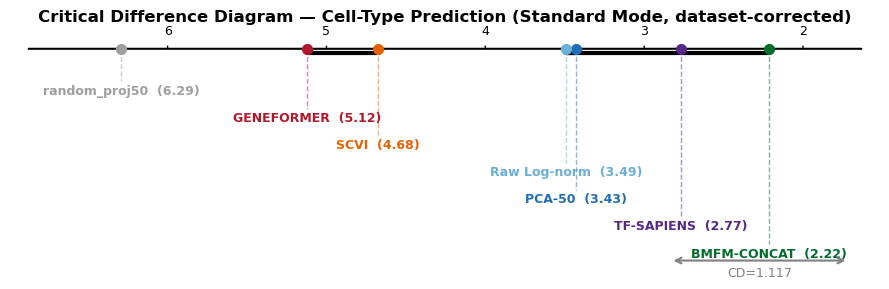

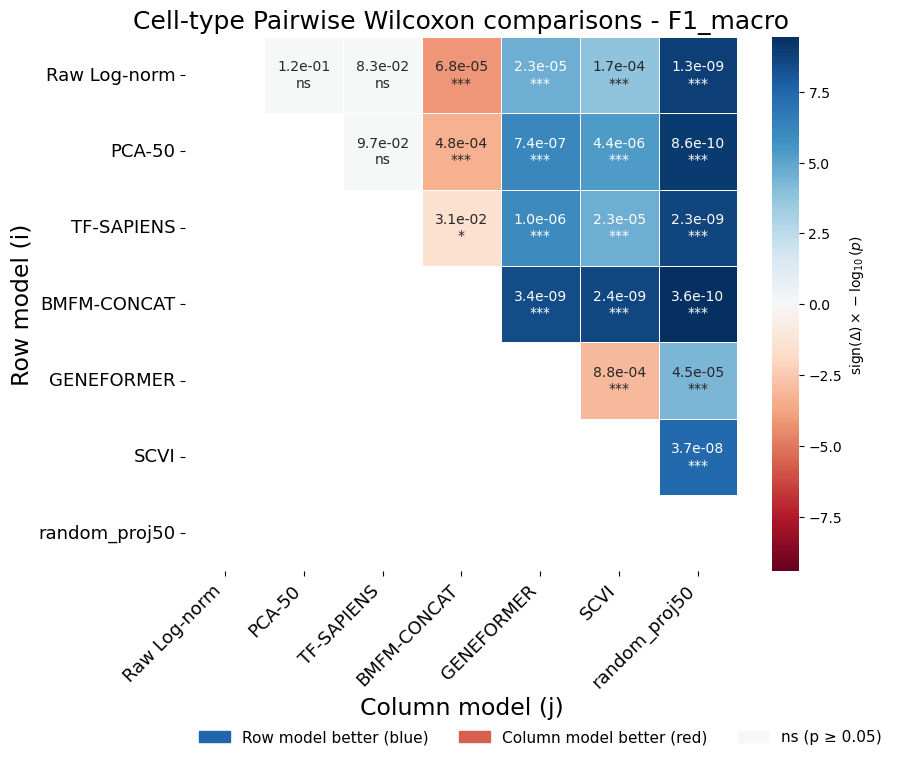

In [18]:
celltype_results = friedman_analysis(
    df=df,          # <-- swap to cell-type df
    task_col='dataset_id',            # <-- swap: no composite task_id for cell-type
    dataset_col='dataset_id',         # no-op here, safe to keep
    feature_col='feature_clean',
    metric='F1_macro',
    exclude_features=[],
    alpha=0.05,
    color_map=palette_dict,
    title='Critical Difference Diagram — Cell-Type Prediction (Standard Mode, dataset-corrected)',
    figsize=(9, 3),
)

print('Cell-type average ranks (dataset-corrected):')
print(celltype_results['friedman_results']['avg_ranks'].round(3))
print(f"T = {celltype_results['friedman_results']['T']} (datasets)")

pairwise_df_ct = pairwise_wilcoxon_holm(
    celltype_results["score_matrix"],
    alpha=0.05,
)

fig, ax, score, annot = plot_pairwise_direction_significance_heatmap(
    pairwise_df_ct,
    feature_order=feature_order,
    metric="F1_macro",
    title_prefix= 'Cell-type'
)

In [10]:
fig.savefig("./plots_brief/test_files_pseudobulk_celltype_18_05_final_F1_friW.png", dpi=300, bbox_inches="tight")

Tasks before dropna: 65, after: 65 (0 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (65, 7)  (T=65 tasks, M=7 models)

=== Friedman Test ===
T=65 tasks, M=7 models
Chi² = 188.8112, p = 4.5533e-38
Iman-Davenport F = 60.0626, p = 1.1102e-16
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
BMFM-CONCAT      2.1692
TF-SAPIENS       2.6462
Raw Log-norm     3.5692
PCA-50           3.5846
SCVI             4.6000
GENEFORMER       5.0308
random_proj50    6.4000
Nemenyi CD (alpha=0.05, M=7, T=65): 1.1175

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_delta_i_minus_j  p_raw  p_holm  significant
 BMFM-CONCAT random_proj50                0.1217 0.0000  0.0000         True
      PCA-50 random_proj50                0.1049 0.0000  0.0000         True
Raw Log-norm random_proj50                0.0972 0.0000  0.0000        

ValueError: too many values to unpack (expected 2)

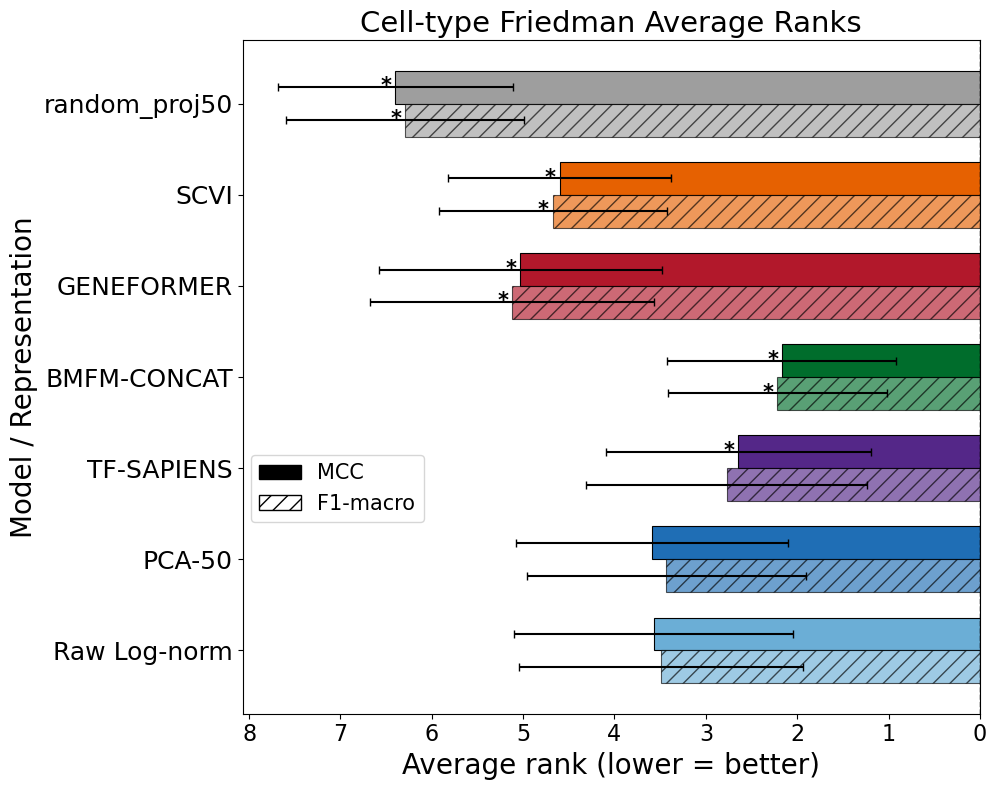

In [19]:


fig, ax = plot_friedman_as_bar(#, summary
    df=df,
    plot_overall_performance_bar=plot_overall_performance_bar,  # your function
    task_col="dataset_id",
    metrics=("MCC", "F1_macro"),
    exclude_features=[],
    feature_order=feature_order,
    color_map=palette_dict,
    figsize=(10, 8),
    errorbar='std',
    title_prefix='Cell-type',
    save_path="./plots_brief/test_files_pseudobulk_celltype_18_05_final_mccF1_fri_std.png",
)

# Low data Mode Results 18 05
24 05

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import functions from evaluation.py (keep evaluation.py unchanged!)
from evaluation import (
    load_and_prepare_results,
    plot_overall_performance,
    plot_pairwise_comparison,
    plot_comparison_matrix,
    plot_task_variability,
    generate_llm_summary,
    add_task_zscore,
    plot_lowdata_with_standard_std,
    plot_overall_performance_bar,
    plot_lowdata_with_standard_zscore,

)

%matplotlib inline

### start

In [16]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_celltype_18_05_results"

v1 = pd.read_parquet(os.path.join(dir_path, "test_files_low_celltype_18_05.parquet"))
v1


,dataset_id,skip_reason,n_missing,fold,n_train,n_test,n_per_class,bootstrap,n_genes,n_cell_types,...,worst_donor_acc,std_donor_acc,n_valid_donors,AUROC_ovr,feature,donor_metric_error,AUROC,AUPRC,error,error_type
0,3966ba97-beb8-4d0b-9954-d3775cd2cd61,missing_cache_files,5.0,None,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,None
1,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,None,NaN,fold_1,22.0,42002.0,2.0,0.0,32876.0,11.0,...,0.146556,0.178366,10.0,NaN,raw_lognorm,None,NaN,NaN,None,None
2,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,None,NaN,fold_1,22.0,42002.0,2.0,0.0,32876.0,11.0,...,0.096794,0.139175,10.0,NaN,raw_pca50,None,NaN,NaN,None,None
3,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,None,NaN,fold_1,22.0,42002.0,2.0,0.0,32876.0,11.0,...,0.115170,0.075579,10.0,0.613472,random_proj50,None,NaN,NaN,None,None
4,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,None,NaN,fold_1,22.0,42002.0,2.0,0.0,32876.0,11.0,...,0.600502,0.072787,10.0,NaN,obsm[scvi],None,NaN,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130008,a199ca73-035d-44e2-9893-4c493151db21,None,NaN,fold_5,11749.0,17073.0,1024.0,4.0,28299.0,13.0,...,0.615548,0.135999,5.0,NaN,obsm[scvi],None,NaN,NaN,None,None
130009,a199ca73-035d-44e2-9893-4c493151db21,None,NaN,fold_5,11749.0,17073.0,1024.0,4.0,28299.0,13.0,...,0.756585,0.081385,5.0,NaN,obsm[geneformer],None,NaN,NaN,None,None
130010,a199ca73-035d-44e2-9893-4c493151db21,None,NaN,fold_5,11749.0,17073.0,1024.0,4.0,28299.0,13.0,...,0.879354,0.037346,5.0,NaN,obsm[tf-sapiens],None,NaN,NaN,None,None
130011,a199ca73-035d-44e2-9893-4c493151db21,None,NaN,fold_5,11749.0,17073.0,1024.0,4.0,28299.0,13.0,...,0.882965,0.035938,5.0,NaN,obsm[tf-exemplar-human],None,NaN,NaN,None,None


In [17]:
pd.crosstab(v1.dataset_id, v1.feature)

feature,obsm[bmfm],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,250,250,250,250,250,250,250,250
0b75c598-0893-4216-afe8-5414cab7739d,250,250,250,250,250,250,250,250
0bc7235a-ae5a-479d-a487-510435377e55,250,250,250,250,250,250,250,250
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,250,250,250,250,250,250,250,250
19e46756-9100-4e01-8b0e-23b557558a4c,250,250,250,250,250,250,250,250
...,...,...,...,...,...,...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,250,250,250,250,250,250,250,250
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,250,250,250,250,250,250,250,250
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,250,250,250,250,250,250,250,250


In [18]:

v2 = pd.read_parquet(os.path.join(dir_path, "test_files_low_celltype_18_05_v2.parquet"))
v2


,fold,n_train,n_test,n_per_class,bootstrap,dataset_id,n_genes,n_cell_types,balanced_acc,MCC,...,worst_donor_acc,std_donor_acc,n_valid_donors,AUROC_ovr,feature,skip_reason,n_missing,AUROC,AUPRC,donor_metric_error
0,fold_1,10.0,4665.0,2.0,0.0,87a06a2a-16c6-42f7-af1b-529fad431051,22696.0,5.0,0.654660,0.307755,...,0.354686,0.118294,2.0,NaN,obsm[bmfm_var1],None,NaN,NaN,NaN,None
1,fold_2,10.0,4969.0,2.0,0.0,87a06a2a-16c6-42f7-af1b-529fad431051,22696.0,5.0,0.850130,0.725816,...,0.680992,0.114400,2.0,0.890682,obsm[bmfm_var1],None,NaN,NaN,NaN,None
2,fold_3,10.0,23020.0,2.0,0.0,87a06a2a-16c6-42f7-af1b-529fad431051,22696.0,5.0,0.806729,0.489336,...,0.525081,0.080191,4.0,NaN,obsm[bmfm_var1],None,NaN,NaN,NaN,None
3,fold_4,10.0,4540.0,2.0,0.0,87a06a2a-16c6-42f7-af1b-529fad431051,22696.0,5.0,0.858016,0.787619,...,0.839730,0.010456,2.0,0.924151,obsm[bmfm_var1],None,NaN,NaN,NaN,None
4,fold_5,10.0,3666.0,2.0,0.0,87a06a2a-16c6-42f7-af1b-529fad431051,22696.0,5.0,0.863286,0.685948,...,0.417266,0.226808,2.0,0.949582,obsm[bmfm_var1],None,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14654,fold_2,7814.0,5231.0,1024.0,3.0,0b75c598-0893-4216-afe8-5414cab7739d,27925.0,9.0,0.880128,0.927041,...,0.912238,0.042236,2.0,NaN,obsm[bmfm_var1],None,NaN,NaN,NaN,None
14655,fold_3,7592.0,7124.0,1024.0,3.0,0b75c598-0893-4216-afe8-5414cab7739d,27925.0,9.0,0.908984,0.872075,...,0.837288,0.060331,3.0,NaN,obsm[bmfm_var1],None,NaN,NaN,NaN,None
14656,fold_1,6671.0,12256.0,1024.0,4.0,0b75c598-0893-4216-afe8-5414cab7739d,27925.0,9.0,0.889427,0.910360,...,0.924524,0.010622,2.0,NaN,obsm[bmfm_var1],None,NaN,NaN,NaN,None
14657,fold_2,7814.0,5231.0,1024.0,4.0,0b75c598-0893-4216-afe8-5414cab7739d,27925.0,9.0,0.880223,0.929852,...,0.912238,0.045325,2.0,NaN,obsm[bmfm_var1],None,NaN,NaN,NaN,None


In [19]:
pd.crosstab(v2.dataset_id, v2.feature)

feature,obsm[bmfm_var1]
dataset_id,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,250
0b75c598-0893-4216-afe8-5414cab7739d,150
0bc7235a-ae5a-479d-a487-510435377e55,250
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,200
19e46756-9100-4e01-8b0e-23b557558a4c,250
...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,250
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,250
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,250


In [20]:

v3 = pd.read_parquet(os.path.join(dir_path, "test_files_low_celltype_18_05_v3.parquet"))
v3


,fold,n_train,n_test,n_per_class,bootstrap,dataset_id,n_genes,n_cell_types,balanced_acc,MCC,...,n_valid_donors,proba_unavailable,feature,AUROC,AUPRC,donor_metric_error,error,error_type,skip_reason,n_missing
0,fold_1,28.0,19943.0,2.0,0.0,965386e9-1e4f-466d-bf59-ebdca4b66b9b,26585.0,14.0,0.604989,0.324562,...,5.0,None,obsm[bmfm_WCED10],NaN,NaN,None,None,None,None,NaN
1,fold_1,28.0,19943.0,2.0,0.0,965386e9-1e4f-466d-bf59-ebdca4b66b9b,26585.0,14.0,0.714810,0.452444,...,5.0,True,obsm[bmfm_MLMMUL],NaN,NaN,None,None,None,None,NaN
2,fold_2,28.0,35303.0,2.0,0.0,965386e9-1e4f-466d-bf59-ebdca4b66b9b,26585.0,14.0,0.679965,0.524551,...,6.0,None,obsm[bmfm_WCED10],NaN,NaN,None,None,None,None,NaN
3,fold_2,28.0,35303.0,2.0,0.0,965386e9-1e4f-466d-bf59-ebdca4b66b9b,26585.0,14.0,0.802205,0.694054,...,6.0,None,obsm[bmfm_MLMMUL],NaN,NaN,None,None,None,None,NaN
4,fold_3,28.0,18790.0,2.0,0.0,965386e9-1e4f-466d-bf59-ebdca4b66b9b,26585.0,14.0,0.649019,0.440452,...,5.0,None,obsm[bmfm_WCED10],NaN,NaN,None,None,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29308,fold_3,7648.0,34649.0,1024.0,4.0,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.971191,0.971219,...,3.0,True,obsm[bmfm_MLMMUL],NaN,NaN,None,None,None,None,NaN
29309,fold_4,8222.0,18239.0,1024.0,4.0,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.921829,0.950352,...,2.0,True,obsm[bmfm_WCED10],NaN,NaN,None,None,None,None,NaN
29310,fold_4,8222.0,18239.0,1024.0,4.0,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.977221,0.986526,...,2.0,True,obsm[bmfm_MLMMUL],NaN,NaN,None,None,None,None,NaN
29311,fold_5,8184.0,15071.0,1024.0,4.0,c893ddc3-f25b-45e2-8c9e-155918b4261c,31450.0,9.0,0.917624,0.933138,...,2.0,True,obsm[bmfm_WCED10],NaN,NaN,None,None,None,None,NaN


In [21]:
pd.crosstab(v3.dataset_id, v3.feature)

feature,obsm[bmfm_MLMMUL],obsm[bmfm_WCED10]
dataset_id,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,250,250
0b75c598-0893-4216-afe8-5414cab7739d,150,150
0bc7235a-ae5a-479d-a487-510435377e55,250,250
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,200,200
19e46756-9100-4e01-8b0e-23b557558a4c,250,250
...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,250,250
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,250,250
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,250,250


In [ ]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_celltype_18_05_results"

# Get all parquet files
files = glob.glob(os.path.join(dir_path, "*.parquet"))

# Read and concatenate
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df

In [22]:

df = pd.concat([v1, v2 ,v3], ignore_index=True)
df

,dataset_id,skip_reason,n_missing,fold,n_train,n_test,n_per_class,bootstrap,n_genes,n_cell_types,...,worst_donor_acc,std_donor_acc,n_valid_donors,AUROC_ovr,feature,donor_metric_error,AUROC,AUPRC,error,error_type
0,3966ba97-beb8-4d0b-9954-d3775cd2cd61,missing_cache_files,5.0,None,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,None
1,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,None,NaN,fold_1,22.0,42002.0,2.0,0.0,32876.0,11.0,...,0.146556,0.178366,10.0,NaN,raw_lognorm,None,NaN,NaN,None,None
2,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,None,NaN,fold_1,22.0,42002.0,2.0,0.0,32876.0,11.0,...,0.096794,0.139175,10.0,NaN,raw_pca50,None,NaN,NaN,None,None
3,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,None,NaN,fold_1,22.0,42002.0,2.0,0.0,32876.0,11.0,...,0.115170,0.075579,10.0,0.613472,random_proj50,None,NaN,NaN,None,None
4,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,None,NaN,fold_1,22.0,42002.0,2.0,0.0,32876.0,11.0,...,0.600502,0.072787,10.0,NaN,obsm[scvi],None,NaN,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173980,c893ddc3-f25b-45e2-8c9e-155918b4261c,None,NaN,fold_3,7648.0,34649.0,1024.0,4.0,31450.0,9.0,...,0.979322,0.003995,3.0,NaN,obsm[bmfm_MLMMUL],None,NaN,NaN,None,None
173981,c893ddc3-f25b-45e2-8c9e-155918b4261c,None,NaN,fold_4,8222.0,18239.0,1024.0,4.0,31450.0,9.0,...,0.965397,0.006360,2.0,NaN,obsm[bmfm_WCED10],None,NaN,NaN,None,None
173982,c893ddc3-f25b-45e2-8c9e-155918b4261c,None,NaN,fold_4,8222.0,18239.0,1024.0,4.0,31450.0,9.0,...,0.992149,0.000392,2.0,NaN,obsm[bmfm_MLMMUL],None,NaN,NaN,None,None
173983,c893ddc3-f25b-45e2-8c9e-155918b4261c,None,NaN,fold_5,8184.0,15071.0,1024.0,4.0,31450.0,9.0,...,0.960879,0.003585,2.0,NaN,obsm[bmfm_WCED10],None,NaN,NaN,None,None


In [23]:
pd.crosstab(df.dataset_id, df.feature)

feature,obsm[bmfm],obsm[bmfm_MLMMUL],obsm[bmfm_WCED10],obsm[bmfm_var1],obsm[geneformer],obsm[scvi],obsm[tf-exemplar-human],obsm[tf-sapiens],random_proj50,raw_lognorm,raw_pca50
dataset_id,,,,,,,,,,,
01ad3cd7-3929-4654-84c0-6db05bd5fd59,250,250,250,250,250,250,250,250,250,250,250
0b75c598-0893-4216-afe8-5414cab7739d,250,150,150,150,250,250,250,250,250,250,250
0bc7235a-ae5a-479d-a487-510435377e55,250,250,250,250,250,250,250,250,250,250,250
0f4865d5-8000-4f68-8ac7-f5efea9e5e70,250,200,200,200,250,250,250,250,250,250,250
19e46756-9100-4e01-8b0e-23b557558a4c,250,250,250,250,250,250,250,250,250,250,250
...,...,...,...,...,...,...,...,...,...,...,...
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,250,250,250,250,250,250,250,250,250,250,250
ebc2e1ff-c8f9-466a-acf4-9d291afaf8b3,250,250,250,250,250,250,250,250,250,250,250
edc8d3fe-153c-4e3d-8be0-2108d30f8d70,250,250,250,250,250,250,250,250,250,250,250


In [ ]:
import pandas as pd
import glob
import os

# Path to your directory
dir_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_celltype_18_05_results"

# Get all parquet files
files = glob.glob(os.path.join(dir_path, "*.parquet"))

# Read and concatenate
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df

In [24]:
df.to_parquet("/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_celltype_18_05_results/test_files_low_celltype_18_05_final.parquet")

## 2. Load and Prepare Results

In [22]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_low_celltype_18_05_results/test_files_low_celltype_18_05_final1632.parquet"
df = load_and_prepare_results(parquet_path)

print(f"After filtering (errors/skips removed):")
print(f"  Total rows: {len(df):,}")
print(f"  Unique tasks: {df['task_id'].nunique()}")
print(f"  Features: {sorted(df['feature_clean'].unique())}")
print(f"\nSample:")
df[['task_id', 'fold', 'feature_clean', 'MCC', 'balanced_acc', 'F1_macro']].head(8) 

After filtering (errors/skips removed):
  Total rows: 174,590
  Unique tasks: 65
  Features: ['BMFM-CONCAT', 'BMFM_BW', 'BMFM_LM', 'BMFM_LW', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-EXEMPLAR-HUMAN', 'TF-SAPIENS', 'random_proj50']

Sample:


,task_id,fold,feature_clean,MCC,balanced_acc,F1_macro
0,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,fold_1,Raw Log-norm,0.391063,0.368231,0.212060
1,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,fold_1,PCA-50,0.275437,0.325589,0.264415
2,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,fold_1,random_proj50,0.080161,0.163371,0.109955
3,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,fold_1,SCVI,0.674881,0.675453,0.518464
4,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,fold_1,GENEFORMER,0.456600,0.633257,0.440152
5,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,fold_1,TF-SAPIENS,0.906872,0.884539,0.848289
6,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,fold_1,TF-EXEMPLAR-HUMAN,0.903094,0.863609,0.819438
7,8f4f8502-9170-4ac2-9707-3b6985ebfe5f,fold_1,BMFM_LW,0.726101,0.667817,0.591928


In [23]:
feature_order = [ 'Raw Log-norm', 'PCA-50', 'TF-SAPIENS', 'BMFM-CONCAT', 'GENEFORMER', 'SCVI', 'random_proj50']

In [24]:
df= df.query('feature_clean.isin(@feature_order)')

In [25]:
from feature_colors import  get_palette
palette = get_palette(feature_order)
palette_dict = dict(zip(feature_order, palette))  # Create dict from list

## 3. Overall Performance

In [26]:
df['fold'] = df['fold'].str.replace('fold_', '').astype(int)


In [27]:
parquet_path = "/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/tfm-embed-predict/test_files_standard_celltype_18_05_results/test_files_standard_celltype_18_05_final.parquet"
df_standard = load_and_prepare_results(parquet_path)

df_lowdata=df.copy()

In [28]:
df_standard= df_standard.query('feature_clean.isin(@feature_order)')

In [30]:
import importlib
import evaluation
importlib.reload(evaluation)

from evaluation import  *

Saved: ./plots_brief/test_files_low_celltype_18_05_results_lowF1.png


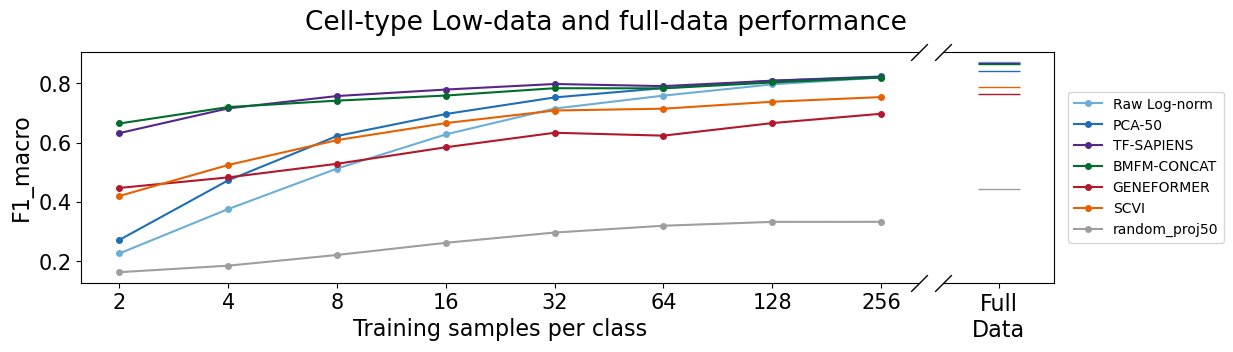

In [31]:
df_lowdata = df_lowdata[~df_lowdata['n_per_class'].isin([1024,512])]

fig = plot_lowdata_with_standard_std(
    df_lowdata=df_lowdata,
    df_standard=df_standard,
    feature_order=feature_order,
    palette_dict=palette_dict,
    metrics=[ "F1_macro"],
    show_error=False,figsize_per_row=(14, 3),
    title_prefix='Cell-type',
    save_path="./plots_brief/test_files_low_celltype_18_05_results_lowF1.png"

)

plt.show()

## rank-based Demšar-style

### freidman corrected 20 08

In [32]:
from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar, run_friedman_per_nperclass, plot_lowdata_ranks_with_standard)

In [33]:
import importlib
import friedman_ranking
importlib.reload(friedman_ranking)

from friedman_ranking import ( prepare_score_matrix, plot_cd_diagram, friedman_analysis, pairwise_wilcoxon_holm, plot_friedman_as_bar, run_friedman_per_nperclass, plot_lowdata_ranks_with_standard)


##################################################
METRIC: F1_macro

n_per_class = 2.0
Tasks before dropna: 65, after: 65 (0 dropped due to missing features)
Features: ['BMFM-CONCAT', 'GENEFORMER', 'PCA-50', 'Raw Log-norm', 'SCVI', 'TF-SAPIENS', 'random_proj50']
Score matrix shape: (65, 7)  (T=65 tasks, M=7 models)

=== Friedman Test ===
T=65 tasks, M=7 models
Chi² = 345.1978, p = 1.6570e-71
Iman-Davenport F = 493.1155, p = 1.1102e-16
Significant at alpha=0.05: True

Average ranks (lower = better):
feature_clean
BMFM-CONCAT      1.3538
TF-SAPIENS       1.8154
GENEFORMER       3.4154
SCVI             3.5846
PCA-50           5.2000
Raw Log-norm     5.9077
random_proj50    6.7231

=== Pairwise Wilcoxon + Holm (21 pairs, alpha=0.05) ===
   feature_i     feature_j  mean_delta_i_minus_j  p_raw  p_holm  significant
  GENEFORMER random_proj50                0.2841 0.0000  0.0000         True
        SCVI    TF-SAPIENS               -0.2121 0.0000  0.0000         True
Raw Log-norm    TF-SAPIEN

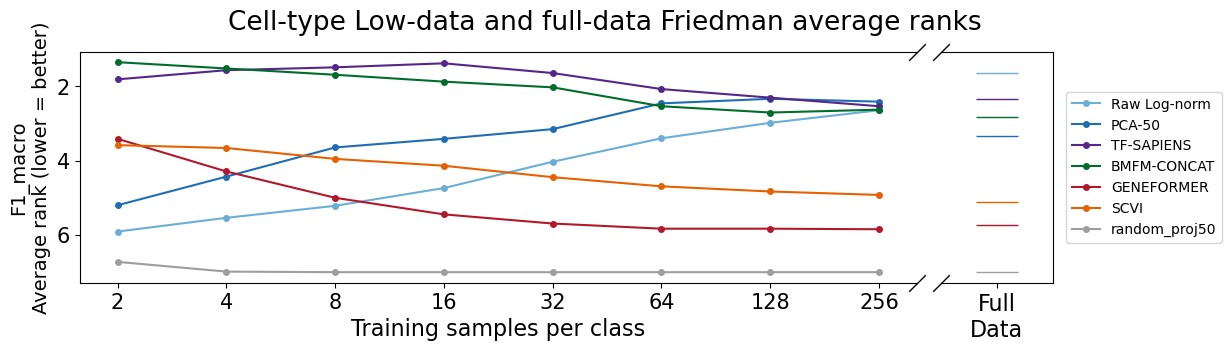

In [34]:
ranks_df, pairwise_df = run_friedman_per_nperclass(
    df_lowdata, df_standard,
    task_col="dataset_id",
    metrics=["F1_macro"],   # ← list now
    exclude_features=[None],
    alpha=0.05,
)
ranks_df = ranks_df[~ranks_df['n_per_class'].isin([1024,512])]
fig = plot_lowdata_ranks_with_standard(
    ranks_df,
    feature_order=feature_order,
    palette_dict=palette_dict,
    metrics=["F1_macro"],   # ← list now
    xticks = [2, 4, 8, 16, 32, 64, 128, 256],
    figsize_per_row=(14, 3),       # ← per row, total height = 10
    title_prefix='Cell-type',
    save_path="./plots_brief/test_files_low_celltype_18_05_results_lowF1_fri.png",
)